# DeepAFM

## Tutorial Overview

This notebook demonstrates transfer learning of a denoising task to MgtE-NDs.
We will execute both standard weight initialization and transfer learning approaches.

### What you'll learn:
1. **AFM Image Generation** - Generate 10,000 synthetic AFM images from protein structure
2. **Dataset Creation** - Build train/val/test datasets in WebDataset format with data augmentation (white noise, translation)
3. **Model Training** - Train a ViT-based Autoencoder on MgtE-NDs data (30 epochs)
4. **Evaluation** - Compute reconstruction quality (MSE/MAE), and visualize denoising result
5. **Transfer Learning** - Fine-tune the pretrained model on MgtE-NDs data
6. **Transfer Learning Training** - Fine-tune the pretrained model on MgtE-NDs data (30 epochs)
7. **Transfer Learning Evaluation** - Compute reconstruction quality (MSE/MAE), and visualize denoising result

### Specifications:
| Item | Value |
|------|-------|
| **Images** | 10,000 total (train/val/test split) |
| **Image size** | 36×36 pixels |
| **Scale** | 0.8 nm/pixel |
| **Model** | ViT Autoencoder |
| **Encoder** | 12 layers, 512 dim, 8 heads |
| **Decoder** | 8 layers, 256 dim, 4 heads |
| **Task** | denoising |
| **Batch size** | 64 |
| **Estimated time** | ~40 minutes (GPU recommended) |

### Requirements
- GPU is recommended (CPU is supported but slower).
- 2.5 GB disk space for generated data and model outputs.
- Python packages from `requirements.txt`.
- **Zenodo dataset is required**:
  1. Download `18587081.zip` from Zenodo.
  2. Place it in the repository root.
  3. Run `bash setup.sh` to extract data into `data/md_raw/` and pretrained weights into `runs/pretrained_model/`

## Setting

In [1]:
# Get current working directory and add ./src to sys.path
import os
import sys
from pathlib import Path
import torch

cwd = Path.cwd()
src_path = cwd / "src"

if src_path.exists():
    if str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))
        print("Inserted src into sys.path")
    else:
        print("src already in sys.path")
        
else:
    print("No src directory found at expected path:", src_path)

Inserted src into sys.path


In [2]:
# Experiment Configuration
from configs.experiment_config import ExperimentConfig
from utils.setup_utils import make_experiment_dirs

# Define experiment configuration
protein_of_project = "MgtE_NDs"
exp_id = "Tutorial_of_{}".format(protein_of_project)

exp_cfg = ExperimentConfig(
    protein_of_project=protein_of_project,
    exp_id=exp_id, 
    scan_direction="x",
)

description = "DeepAFM tutorial experiment for protein {}".format(protein_of_project)
exp_cfg.description = description

make_experiment_dirs(exp_cfg)  # Create experiment directories


## AFM image Generation

In [3]:
from afm_image_generation.core.afm_image_generator_multiprocess import AFMImageGenerator_Multiprocess
from dataload.split_manager import split_and_move_data

### Configure Generation Parameters

In [4]:
# Make run name and save configuration
exp_cfg.system.run_name = exp_id

# Set SEED
exp_cfg.system.seed = 42 

# PDB file path settings
exp_cfg.data_dir.pdb_path = os.path.join(
    exp_cfg.data_dir.md_dir,
    "2zy9_NDs.pdb"  # PDB file containing MD simulation frames (PDB: 2zy9)
)
exp_cfg.data_dir.dcd_path = None  # DCD file path (not used in this experiment)
exp_cfg.system.pdb_only = True    # Set to True to use only PDB files for AFM image generation

# AFM Image Generation Settings
# save mode settings
exp_cfg.system.md_load_mode = "coarse"   # "all_atom", "coarse" 
exp_cfg.system.save_mode = "webdataset"  # Options: "hdf5", "tfrecord", "webdataset"
exp_cfg.system.use_gpu_for_afm = False     
exp_cfg.system.device = "cpu"

# Set AFM image generation parameters
exp_cfg.afm.random.scan_preset_list = [
    {"scale_x": 0.8, "scale_y": 0.8, "width_px": 36, "height_px": 36}
    ]
exp_cfg.afm.fixed.fixed_width_px = 36        # Set fixed width in pixels for saving AFM images
exp_cfg.afm.fixed.fixed_height_px = 36       # Set fixed height in pixels for saving AFM images

# range -> list
exp_cfg.afm.random.__post_init__()  
exp_cfg.afm.random.pdb_num_list = [1]             # Set PDB frame number list (PDB: 2zy9) 

# AFM job settings
exp_cfg.afm.job.total_images = 10000              # Number of AFM images to generate
exp_cfg.afm.job.processes = 32                    # Number of processes for AFM image generation
exp_cfg.afm.job.chunk_size = 1000                 # Chunk size for saving AFM image
exp_cfg.afm.job.vectorized = False                # execute AFM image generation in vectorized mode
exp_cfg.afm.job.output_mode = [                   # Output mode for AFM image generation
    "distorted",  # Distorted AFM image accounting for asynchronous measurement times
    "ideal",      # Instantaneous AFM image
    "config"      # Parameters used for image generation
]

# save experiment configuration to YAML file
exp_cfg.save_yaml()  # Save the configuration to a YAML file


### Generate AFM Images and Split Dataset

In [5]:
# Initialize AFM Image Generator with Multiprocessing
generator = AFMImageGenerator_Multiprocess(exp_cfg)

# Set up and run AFM image generation
generator.setup()
generator.run_parallel_process()

# shut down the generator after completion
generator.shutdown()

# Split generated data into train/val/test sets
save_mode_to_extension = {
    "hdf5": "hdf5",
    "tfrecord": "tfrecord",
    "webdataset": "tar",
}

split_and_move_data(
    exp_cfg, 
    extension=save_mode_to_extension[exp_cfg.system.save_mode]
    )


AFMInputGenerator: parameter_mode = random
[AFM Multiprocess] Configured for 10000 images using 32 processes with chunk size 1000.
[AFM Multiprocess] Use GPU for AFM: False
[AFM Multiprocess] Save mode set to: webdataset
[AFM Multiprocess] Scan direction: x, Scan unit: line


2026-03-04 19:09:56,133	INFO worker.py:1951 -- Started a local Ray instance.


2026-03-04 19:09:56,366	INFO packaging.py:588 -- Creating a file package for local module '/home/ksatou/2025_DeepAFM_Pytorch/DeepAFM/src'.


2026-03-04 19:09:56,522	INFO packaging.py:380 -- Pushing file package 'gcs://_ray_pkg_2acca3993957051d.zip' (37.90MiB) to Ray cluster...


2026-03-04 19:09:56,666	INFO packaging.py:393 -- Successfully pushed file package 'gcs://_ray_pkg_2acca3993957051d.zip'.


...

[WebDataset] Saved chunk → data/Tutorial_of_MgtE_NDs/afm_generated/42_0008.tar


[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.


[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.


[WebDataset] Saved chunk → data/Tutorial_of_MgtE_NDs/afm_generated/42_0009.tar


[Shutdown] Ray environment closed successfully.


## Data loader

In [6]:
from dataload.webdataset_loader import create_afm_dataloader
from dataload.preprocess import AFMPreprocess

# device settings for data loading and preprocessing
exp_cfg.system.device = "cuda" if torch.cuda.is_available() else "cpu"

# set data load modes
exp_cfg.system.data_load_mode = ["distorted", "ideal", "config"]

# set preprocess and data augmentation 
# add white noise option
exp_cfg.data.add_white_noise = True
exp_cfg.data.noise_std_range = (0.0, 0.3, 0.01)  # Range of noise stddev for augmentation

# translation range in pixels
exp_cfg.data.translation_x_pixel = (-3, 3, 1)    # set translation range in pixels
exp_cfg.data.translation_y_pixel = (-3, 3, 1)    # set translation range in pixels
exp_cfg.data.__post_init__()                    # expand ranges to lists

# scaling option
exp_cfg.data.min_max_scaling = True

# pdb number to state mapping
exp_cfg.data.pdb_num_to_state = False           # enable pdb_num to state mapping
exp_cfg.train.batch_size = 64                   # Batch size for training

# task mode
exp_cfg.train.task_mode = "denoise"               # "denoise" or "multitask"

# save experiment configuration to YAML file
exp_cfg.save_yaml()  # Save the configuration to a YAML file

train_dataloader = create_afm_dataloader(
    url_pattern=os.path.join(exp_cfg.data_dir.train_data_dir, "*.tar"), 
    exp_cfg=exp_cfg,
    shuffle=True
    )

val_dataloader = create_afm_dataloader(
    url_pattern=os.path.join(exp_cfg.data_dir.val_data_dir, "*.tar"), 
    exp_cfg=exp_cfg,
    shuffle=False
    )

# preprocessor for visualization (no min-max scaling)
preprocessor = AFMPreprocess(
    exp_cfg=exp_cfg,
    add_white_noise=False,
    translate=False,
    min_max_scaling=False,
    pdb_num_to_state=False,
    )

test_dataloader_for_vis = create_afm_dataloader(
    url_pattern=os.path.join(exp_cfg.data_dir.test_data_dir, "*.tar"), 
    exp_cfg=exp_cfg,
    preprocessor=preprocessor,
    shuffle=False
    )

# preprocessor for visualization (no min-max scaling)
preprocessor = AFMPreprocess(
    exp_cfg=exp_cfg,
    add_white_noise=False,
    translate=False,
    min_max_scaling=True,
    pdb_num_to_state=False,
    )

test_dataloader_for_eval = create_afm_dataloader(
    url_pattern=os.path.join(exp_cfg.data_dir.test_data_dir, "*.tar"), 
    exp_cfg=exp_cfg,
    preprocessor=preprocessor,
    shuffle=False
    )

## Training

In [7]:
from configs.nn_config import ViTAutoEncoderConfig
from models.ViT_AutoEncoder import ViTAutoEncoder
from builders.loss_builder import build_loss
from builders.metrics_builder import build_metrics  
from builders.optimizer_builder import build_optimizer
from builders.scheduler_builder import build_scheduler
from training.trainer import ModelTrainer

In [8]:
# Training ViT for DeepAFM
exp_cfg.system.run_name = exp_id
exp_cfg.system.nn_dtype = "fp32" 
exp_cfg.system.save_interval = 30 # Save model every 30 epochs 
exp_cfg.train.use_amp = True      # If use GPU with AMP, set to True is recommended

# Set ViT model parameters
exp_cfg.model = ViTAutoEncoderConfig()             # Use ViTAutoEncoderConfig for AE
exp_cfg.model.image_size = 36                      # Image size for ViT
exp_cfg.model.patch_size = 3                       # Patch size for ViT
exp_cfg.model.enc_embed_dim = 512                  # Embedding dimension for ViT
exp_cfg.model.enc_depth = 12                       # Depth of ViT model
exp_cfg.model.enc_num_heads = 8                    # Number of attention heads for ViT
exp_cfg.model.enc_mlp_ratio = 4                    # MLP ratio for ViT

exp_cfg.model.dec_embed_dim = 256                  # Embedding dimension for ViT
exp_cfg.model.dec_depth = 8                        # Depth of ViT model
exp_cfg.model.dec_num_heads = 4                    # Number of attention heads for ViT
exp_cfg.model.dec_mlp_ratio = 4                    # MLP ratio for ViT

# scheduler settings
exp_cfg.train.scheduler = "cosine"                 # Learning rate scheduler type

# dataload settings
exp_cfg.data.num_workers = 32                     # Number of worker processes for data loading
exp_cfg.data.prefetch_size = 1                    # Prefetch size for data loading

# Set training parameters for ViT
exp_cfg.train.epochs =30                          # Number of training epochs
# task mode
exp_cfg.train.task_mode = "denoise"               # "denoise" or "multitask"
exp_cfg.train.recons_loss_type = "mse"            # for denoise/reconstruction task: "mse", "l1", "huber"

# save experiment configuration to YAML file
exp_cfg.save_yaml()  # Save the configuration to a YAML file

In [9]:
#  --- Training ---
model = ViTAutoEncoder.from_config(exp_cfg)

loss_fn, loss_weights = build_loss(exp_cfg)
metrics = build_metrics(exp_cfg)
optimizer = build_optimizer(exp_cfg, model)
scheduler = build_scheduler(exp_cfg, optimizer)

trainer = ModelTrainer(
    exp_cfg=exp_cfg, 
    model=model,
    loss_fn=loss_fn,
    loss_weights=loss_weights,
    metrics=metrics,
    optimizer=optimizer,
    train_loader=train_dataloader, 
    val_loader=val_dataloader,
    scheduler=scheduler
    )

trainer.fit()


[Trainer] No checkpoints found, start from scratch.
[Trainer] Starting training for 30 epochs
[Trainer] Starting training from epoch 1


 >> New Best Model found! Val Loss: 0.006842


[Checkpoint] Saved best model: runs/Tutorial_of_MgtE_NDs/checkpoints/best_model.pt
Epoch 1 | LR: 9.97e-05 | train_loss: 0.0879 | train_loss_ideal: 0.0879 | train_mae: inf | train_mse: 0.0879 | val_loss: 0.0068 | val_loss_ideal: 0.0068 | val_mae: 0.0417 | val_mse: 0.0068


 >> New Best Model found! Val Loss: 0.006149


[Checkpoint] Saved best model: runs/Tutorial_of_MgtE_NDs/checkpoints/best_model.pt
Epoch 2 | LR: 9.89e-05 | train_loss: 0.0085 | train_loss_ideal: 0.0085 | train_mae: 0.0601 | train_mse: 0.0085 | val_loss: 0.0061 | val_loss_ideal: 0.0061 | val_mae: 0.0369 | val_mse: 0.0061


...

[Checkpoint] Saved best model: runs/Tutorial_of_MgtE_NDs/checkpoints/best_model.pt
Epoch 29 | LR: 2.74e-07 | train_loss: 0.0034 | train_loss_ideal: 0.0034 | train_mae: 0.0304 | train_mse: 0.0034 | val_loss: 0.0030 | val_loss_ideal: 0.0030 | val_mae: 0.0240 | val_mse: 0.0030


Epoch 30 | LR: 0.00e+00 | train_loss: 0.0034 | train_loss_ideal: 0.0034 | train_mae: 0.0304 | train_mse: 0.0034 | val_loss: 0.0031 | val_loss_ideal: 0.0031 | val_mae: 0.0241 | val_mse: 0.0031


[Checkpoint] Saved: runs/Tutorial_of_MgtE_NDs/checkpoints/model_epoch30.pt
[Logger] Saved plot: curve_Learning_Rate.png


[Logger] Saved plot: curve_loss.png
[Logger] Saved plot: curve_loss_ideal.png


[Logger] Saved plot: curve_mae.png
[Logger] Saved plot: curve_mse.png


## Evaluation

In [10]:
from evaluation.evaluater import Evaluator

In [11]:
# --- Evaluation ---
model = ViTAutoEncoder.from_config(exp_cfg)
evaluator = Evaluator(
    exp_cfg=exp_cfg, 
    model=model,
    test_data_loader=test_dataloader_for_eval
    )
# Build loss and metrics for evaluation
loss_fn, loss_weights = build_loss(exp_cfg)
metrics = build_metrics(exp_cfg)

#evaluator.load_latest_checkpoint()
evaluator.load_best_checkpoint()

# Compute loss and metrics
results = evaluator.compute_loss_and_metrics(
    loss_fn=loss_fn, 
    loss_weights=loss_weights, 
    metrics=metrics
    )

print(results)

[Evaluator] Loading latest checkpoint: runs/Tutorial_of_MgtE_NDs/checkpoints/model_epoch30.pt


[Evaluator] Loaded model at epoch 30
[Evaluator] Loading best checkpoint: runs/Tutorial_of_MgtE_NDs/checkpoints/best_model.pt


[Evaluator] Loaded model at epoch 29


[Evaluator] Saved evaluation results to runs/Tutorial_of_MgtE_NDs/evaluation_results/evaluation_results.txt
{'test_loss': 0.002959005117416382, 'test_loss_ideal': 0.002959005117416382, 'test_mae': 0.02278662109375, 'test_mse': 0.002959005117416382}


[Evaluator] Loading latest checkpoint: runs/Tutorial_of_MgtE_NDs/checkpoints/model_epoch30.pt


[Evaluator] Loaded model at epoch 30
[Evaluator] Loading best checkpoint: runs/Tutorial_of_MgtE_NDs/checkpoints/best_model.pt


[Evaluator] Loaded model at epoch 29


[Evaluator] Saved evaluation results to runs/Tutorial_of_MgtE_NDs/evaluation_results/evaluation_results.txt
{'test_loss': 0.002959005117416382, 'test_loss_ideal': 0.002959005117416382, 'test_mae': 0.02278662109375, 'test_mse': 0.002959005117416382}


--- Physical Evaluation Results (nm) ---
avg_physical_mse: 0.3356
avg_physical_mae: 0.2427
total_samples: 1000.0000
[Evaluator] Saved physical results to runs/Tutorial_of_MgtE_NDs/evaluation_results/evaluation_results.txt


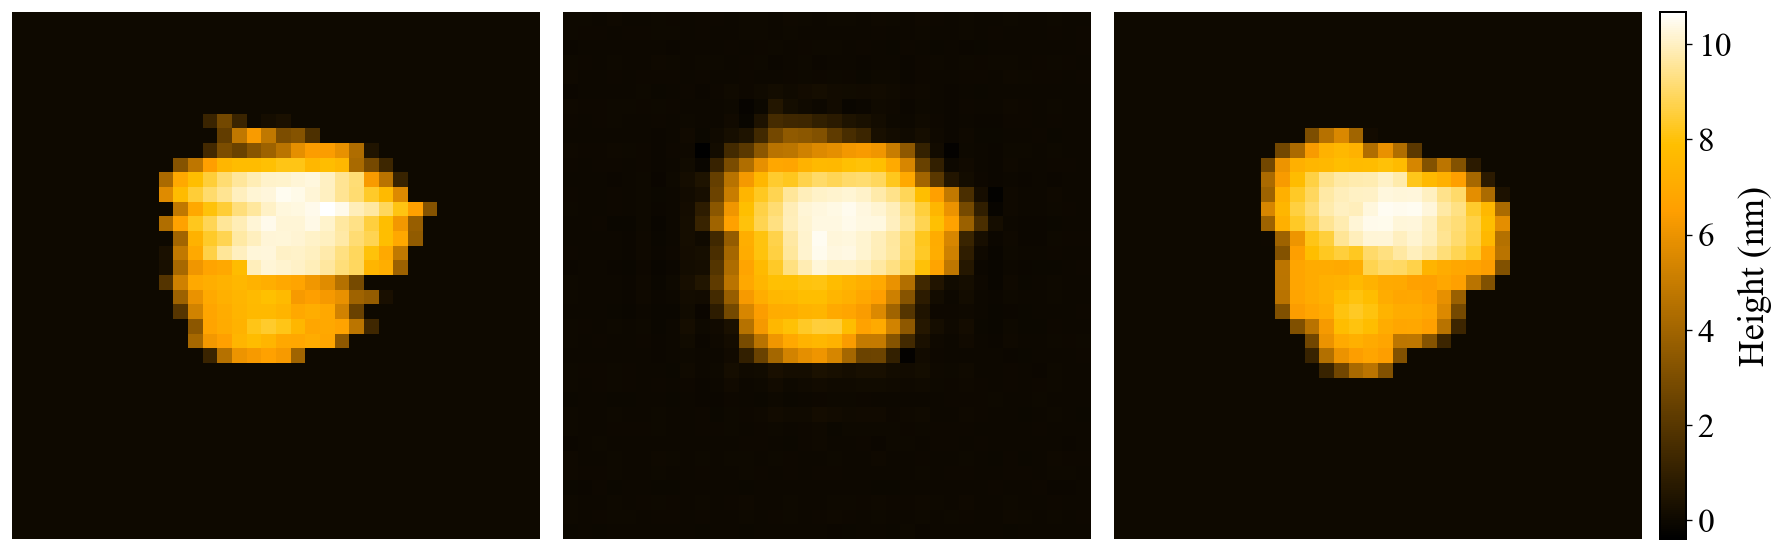

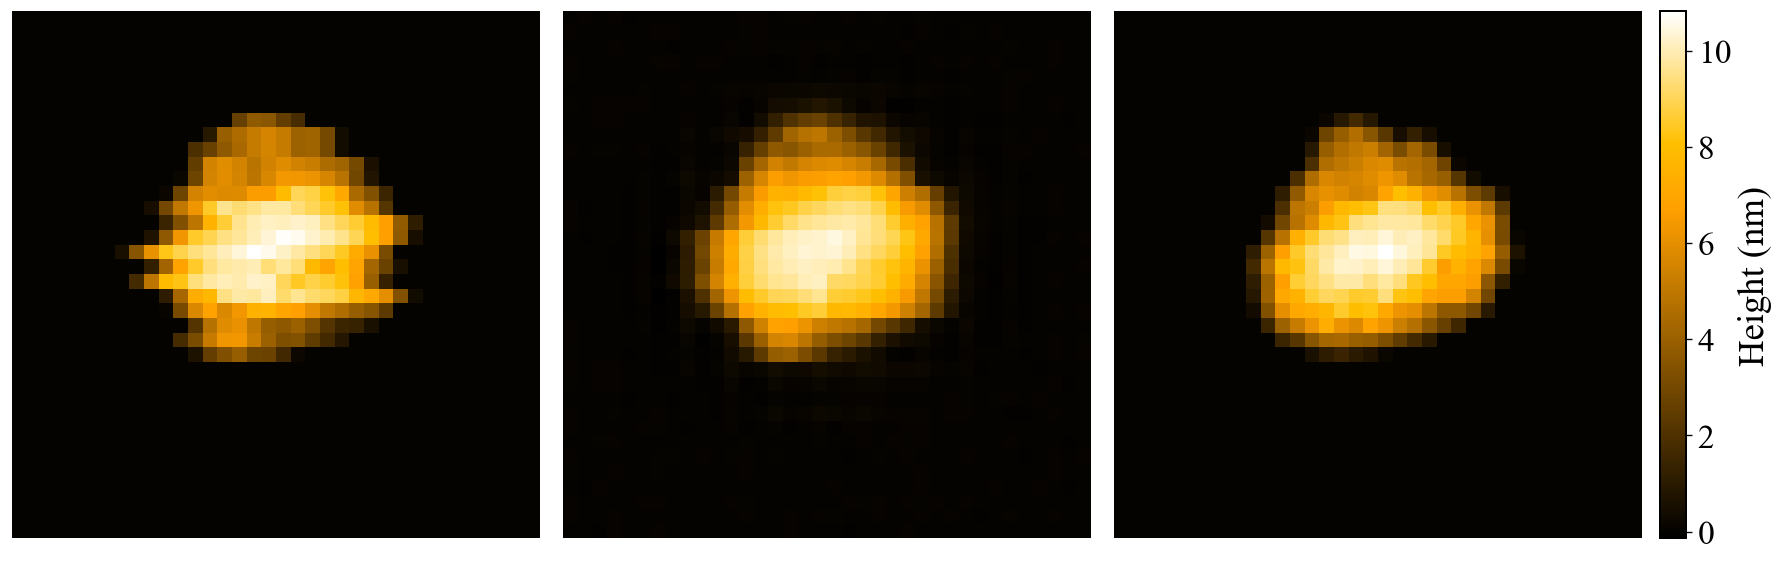

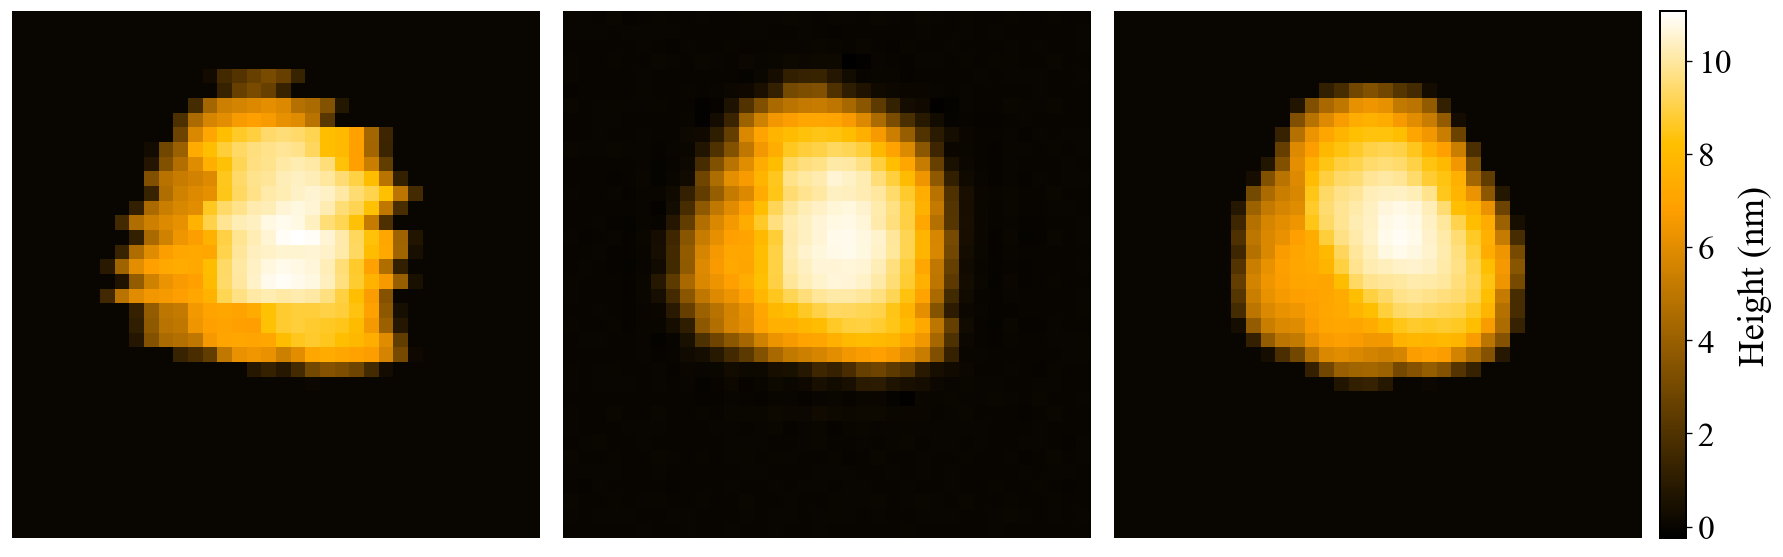

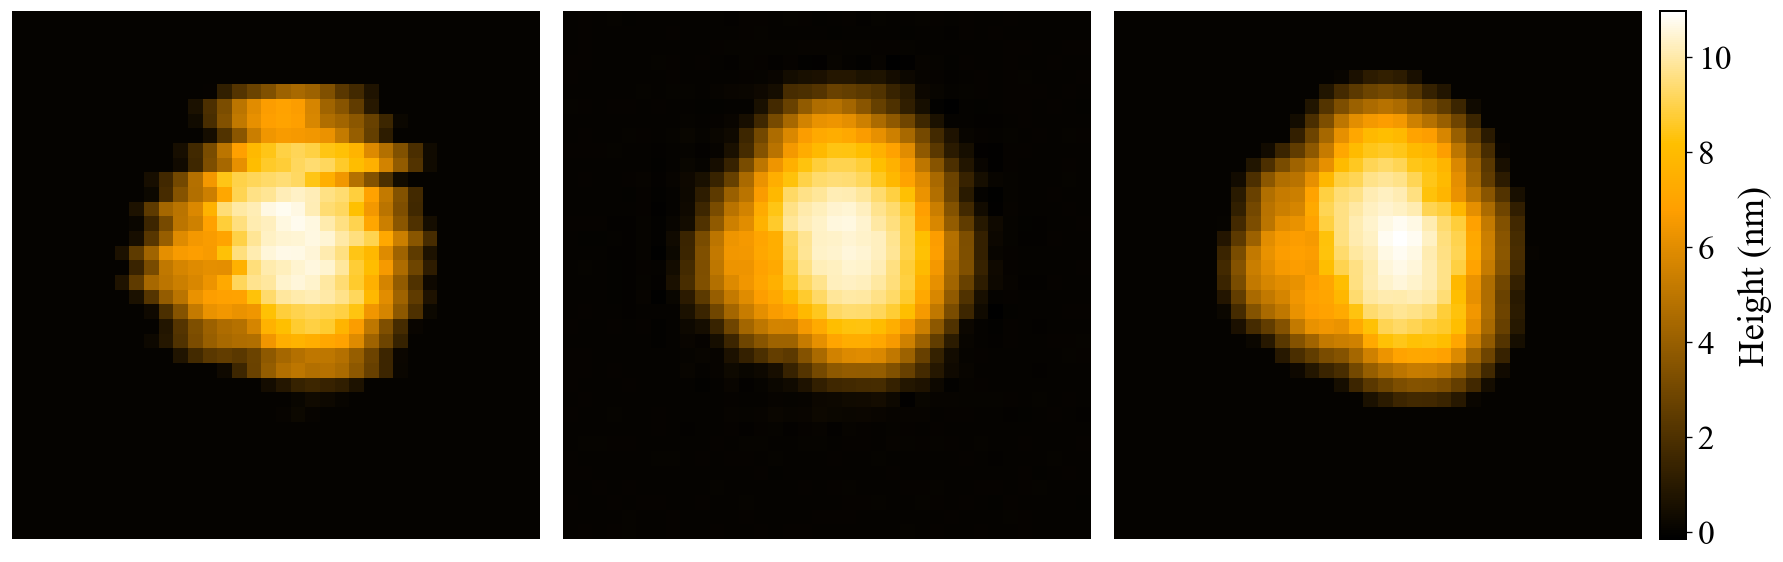

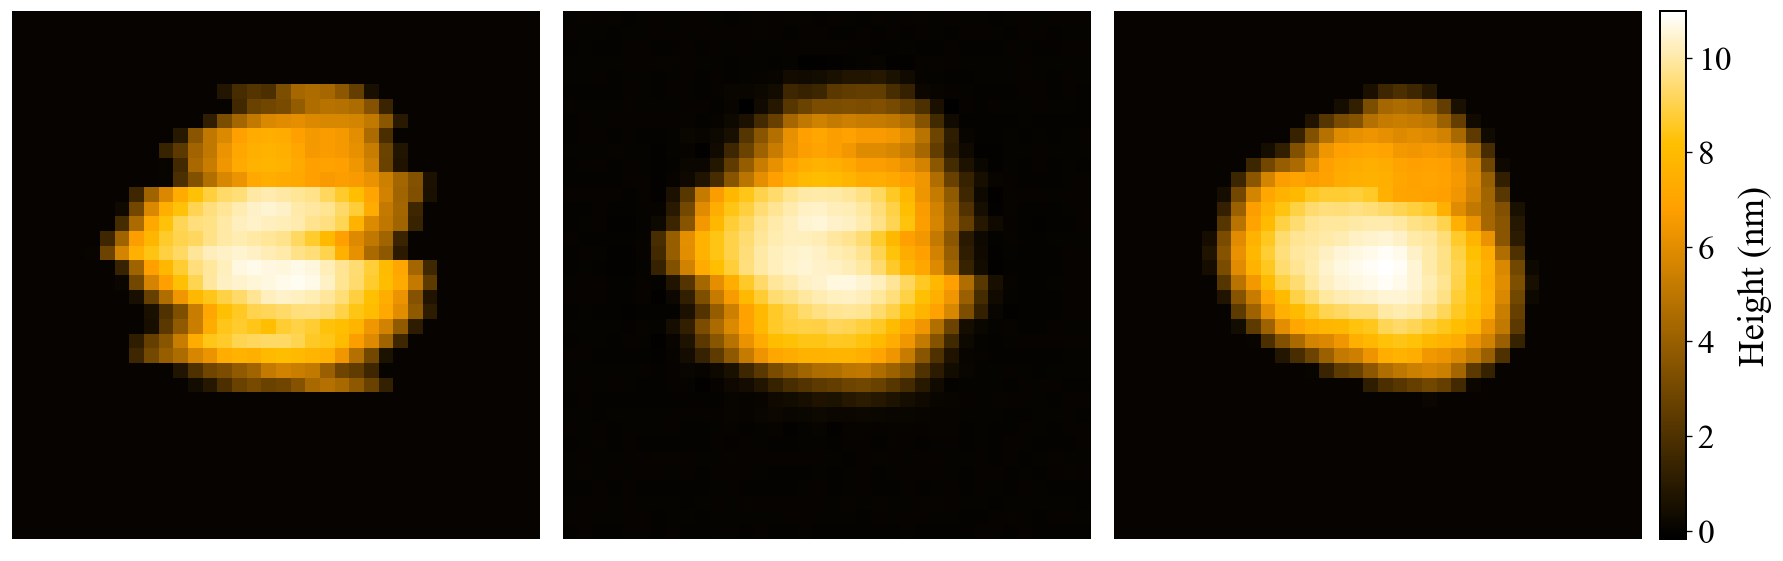

In [12]:
# Visualization
IMG_NUMS = 5
IMAGE_SIZE = exp_cfg.model.image_size

evaluator = Evaluator(
    exp_cfg=exp_cfg, 
    model=model,
    test_data_loader=test_dataloader_for_eval
)

evaluator.load_best_checkpoint()

results = evaluator.compute_loss_and_metrics(
    loss_fn=loss_fn, 
    loss_weights=loss_weights, 
    metrics=metrics
)

print(results)

# MAE MSE (not scaled)
evaluator.compute_physical_metrics(
    dataloader=test_dataloader_for_vis # not scaled is needed for physical metrics
)

# Comprehensive Multi-Task Visualization
evaluator.run_denoise_visualization(
    dataloader=test_dataloader_for_vis,
    num_samples=IMG_NUMS,
    start=(int(IMAGE_SIZE/2), 0),
    angle_deg=0,
    save=False
    )


## Transfer Learning

In [13]:
from models.factory import create_model_from_pretrained
from builders.loss_builder import build_loss
from builders.metrics_builder import build_metrics  
from builders.optimizer_builder import build_optimizer
from builders.scheduler_builder import build_scheduler
from training.trainer import ModelTrainer

In [14]:
# Define experiment configuration
exp_id = "Tutorial_of_{}_transfer".format(protein_of_project)

exp_cfg = ExperimentConfig(
    protein_of_project=protein_of_project,
    exp_id=exp_id, 
    scan_direction="x",
)

description = "DeepAFM tutorial experiment for protein {}".format(protein_of_project)
exp_cfg.description = description

make_experiment_dirs(exp_cfg)  # Create experiment directories


In [15]:
pretrained_dir = os.path.join(cwd, "runs", "pretrained_model")

pretrained_model_path = os.path.join(
    pretrained_dir, 
    "checkpoints", 
    "best_model.pt"
)

config_path = os.path.join(
    pretrained_dir, 
    "config.yaml"
)

exp_cfg.system.save_interval = 30 # Save model every 30 epochs 
exp_cfg.train.use_amp = True      # If use GPU with AMP, set to True is recommended

# scheduler settings
exp_cfg.train.scheduler = "cosine"                 # Learning rate scheduler type

# dataload settings
exp_cfg.data.num_workers = 32                       # Number of worker processes for data loading
exp_cfg.data.prefetch_size = 1                     # Prefetch size for data loading

# Set training parameters for ViT
exp_cfg.train.epochs = 30                         # Number of training epochs
# task mode
exp_cfg.train.task_mode = "denoise"               # "denoise" or "multitask"
exp_cfg.train.recons_loss_type = "mse"            # for denoise/reconstruction task: "mse", "l1", "huber"

exp_cfg.model.patch_size = 3                      # Patch size for ViT

# Create model from pretrained weights and configuration
model = create_model_from_pretrained(
    exp_cfg=exp_cfg,
    checkpoint_path=pretrained_model_path,
    config_path=config_path
)

# save experiment configuration to YAML file
exp_cfg.save_yaml()  # Save the configuration to a YAML file


[Model] Loading pretrained weights with adaptation from: runs/pretrained_model/checkpoints/best_model.pt


## Transfer Learning Training

In [16]:
#  --- Training ---
loss_fn, loss_weights = build_loss(exp_cfg)
metrics = build_metrics(exp_cfg)
optimizer = build_optimizer(exp_cfg, model)
scheduler = build_scheduler(exp_cfg, optimizer)

trainer = ModelTrainer(
    exp_cfg=exp_cfg, 
    model=model,
    loss_fn=loss_fn,
    loss_weights=loss_weights,
    metrics=metrics,
    optimizer=optimizer,
    train_loader=train_dataloader, 
    val_loader=val_dataloader,
    scheduler=scheduler
)

trainer.fit()


[Trainer] No checkpoints found, start from scratch.
[Trainer] Starting training for 30 epochs
[Trainer] Starting training from epoch 1


 >> New Best Model found! Val Loss: 0.003512


[Checkpoint] Saved best model: runs/Tutorial_of_MgtE_NDs_transfer/checkpoints/best_model.pt
Epoch 1 | LR: 9.97e-05 | train_loss: 0.0250 | train_loss_ideal: 0.0250 | train_mae: 0.0808 | train_mse: 0.0250 | val_loss: 0.0035 | val_loss_ideal: 0.0035 | val_mae: 0.0300 | val_mse: 0.0035


 >> New Best Model found! Val Loss: 0.002065


[Checkpoint] Saved best model: runs/Tutorial_of_MgtE_NDs_transfer/checkpoints/best_model.pt
Epoch 2 | LR: 9.89e-05 | train_loss: 0.0034 | train_loss_ideal: 0.0034 | train_mae: 0.0359 | train_mse: 0.0034 | val_loss: 0.0021 | val_loss_ideal: 0.0021 | val_mae: 0.0221 | val_mse: 0.0021


...

Epoch 29 | LR: 2.74e-07 | train_loss: 0.0009 | train_loss_ideal: 0.0009 | train_mae: 0.0141 | train_mse: 0.0009 | val_loss: 0.0008 | val_loss_ideal: 0.0008 | val_mae: 0.0125 | val_mse: 0.0008


Epoch 30 | LR: 0.00e+00 | train_loss: 0.0009 | train_loss_ideal: 0.0009 | train_mae: 0.0141 | train_mse: 0.0009 | val_loss: 0.0008 | val_loss_ideal: 0.0008 | val_mae: 0.0125 | val_mse: 0.0008


[Checkpoint] Saved: runs/Tutorial_of_MgtE_NDs_transfer/checkpoints/model_epoch30.pt
[Logger] Saved plot: curve_Learning_Rate.png


[Logger] Saved plot: curve_loss.png
[Logger] Saved plot: curve_loss_ideal.png


[Logger] Saved plot: curve_mae.png
[Logger] Saved plot: curve_mse.png


## Transfer Learning Evaluation

In [17]:
# --- Evaluation ---
evaluator = Evaluator(
    exp_cfg=exp_cfg, 
    model=model,
    test_data_loader=test_dataloader_for_eval
    )
# Build loss and metrics for evaluation
loss_fn, loss_weights = build_loss(exp_cfg)
metrics = build_metrics(exp_cfg)

#evaluator.load_latest_checkpoint()
evaluator.load_best_checkpoint()

# Compute loss and metrics
results = evaluator.compute_loss_and_metrics(
    loss_fn=loss_fn, 
    loss_weights=loss_weights, 
    metrics=metrics
    )

print(results)

[Evaluator] Loading latest checkpoint: runs/Tutorial_of_MgtE_NDs_transfer/checkpoints/model_epoch30.pt


[Evaluator] Loaded model at epoch 30
[Evaluator] Loading best checkpoint: runs/Tutorial_of_MgtE_NDs_transfer/checkpoints/best_model.pt


[Evaluator] Loaded model at epoch 27


[Evaluator] Saved evaluation results to runs/Tutorial_of_MgtE_NDs_transfer/evaluation_results/evaluation_results.txt
{'test_loss': 0.0007665751576423645, 'test_loss_ideal': 0.0007665751576423645, 'test_mae': 0.012261962890625, 'test_mse': 0.0007665751576423645}


[Evaluator] Loading latest checkpoint: runs/Tutorial_of_MgtE_NDs_transfer/checkpoints/model_epoch30.pt


[Evaluator] Loaded model at epoch 30
[Evaluator] Loading best checkpoint: runs/Tutorial_of_MgtE_NDs_transfer/checkpoints/best_model.pt


[Evaluator] Loaded model at epoch 27


[Evaluator] Saved evaluation results to runs/Tutorial_of_MgtE_NDs_transfer/evaluation_results/evaluation_results.txt
{'test_loss': 0.0007665751576423645, 'test_loss_ideal': 0.0007665751576423645, 'test_mae': 0.012261962890625, 'test_mse': 0.0007665751576423645}


--- Physical Evaluation Results (nm) ---
avg_physical_mse: 0.0870
avg_physical_mae: 0.1308
total_samples: 1000.0000
[Evaluator] Saved physical results to runs/Tutorial_of_MgtE_NDs_transfer/evaluation_results/evaluation_results.txt


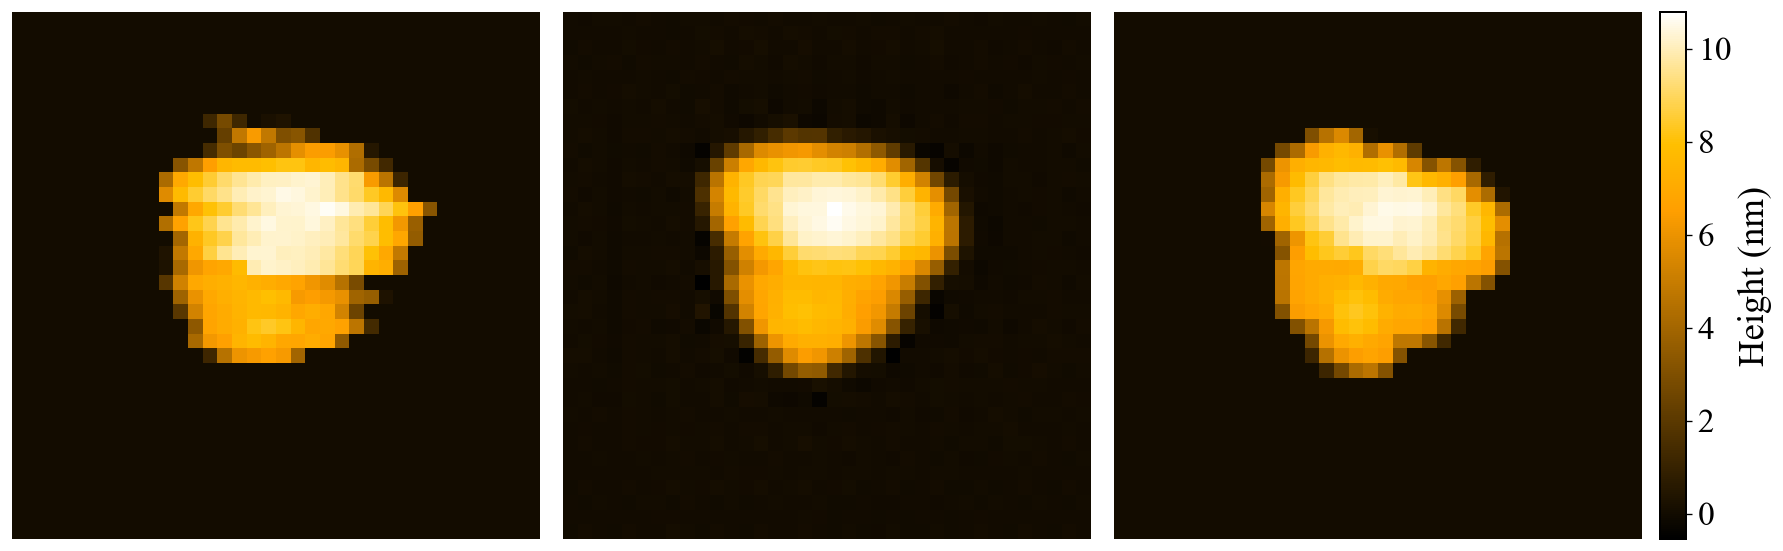

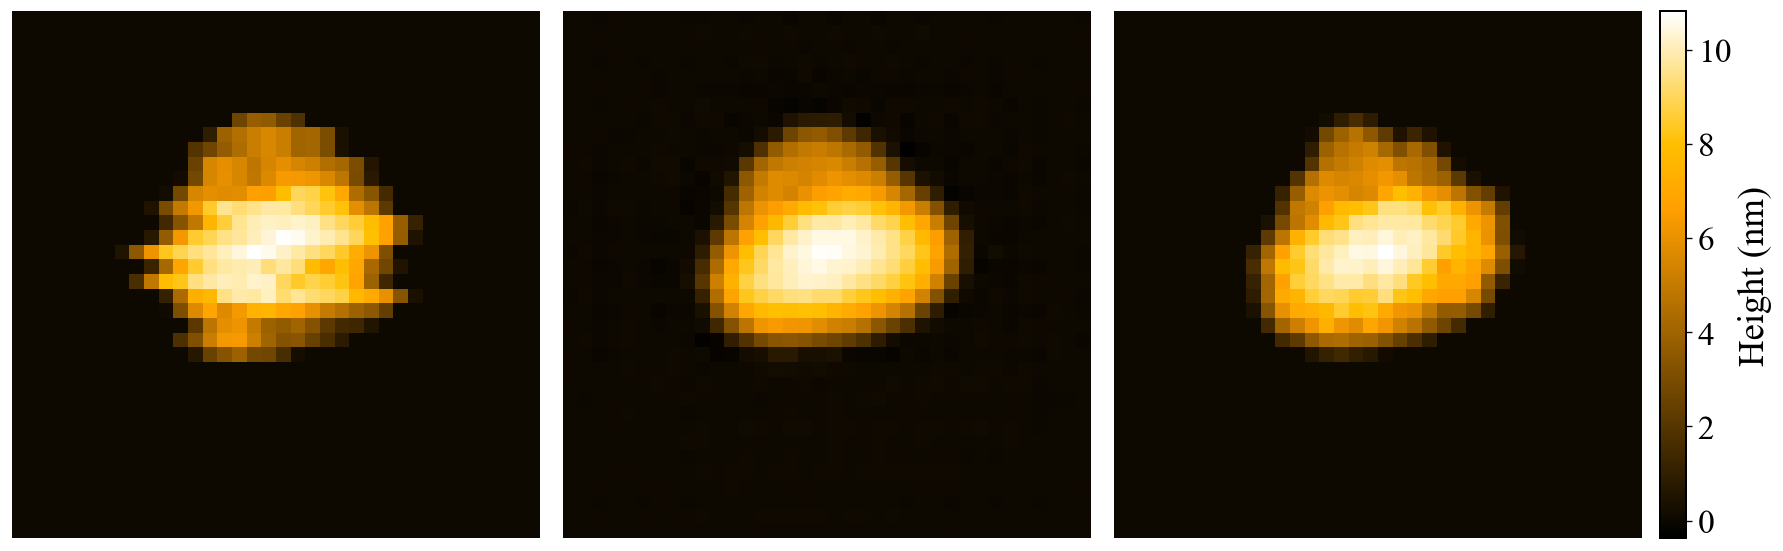

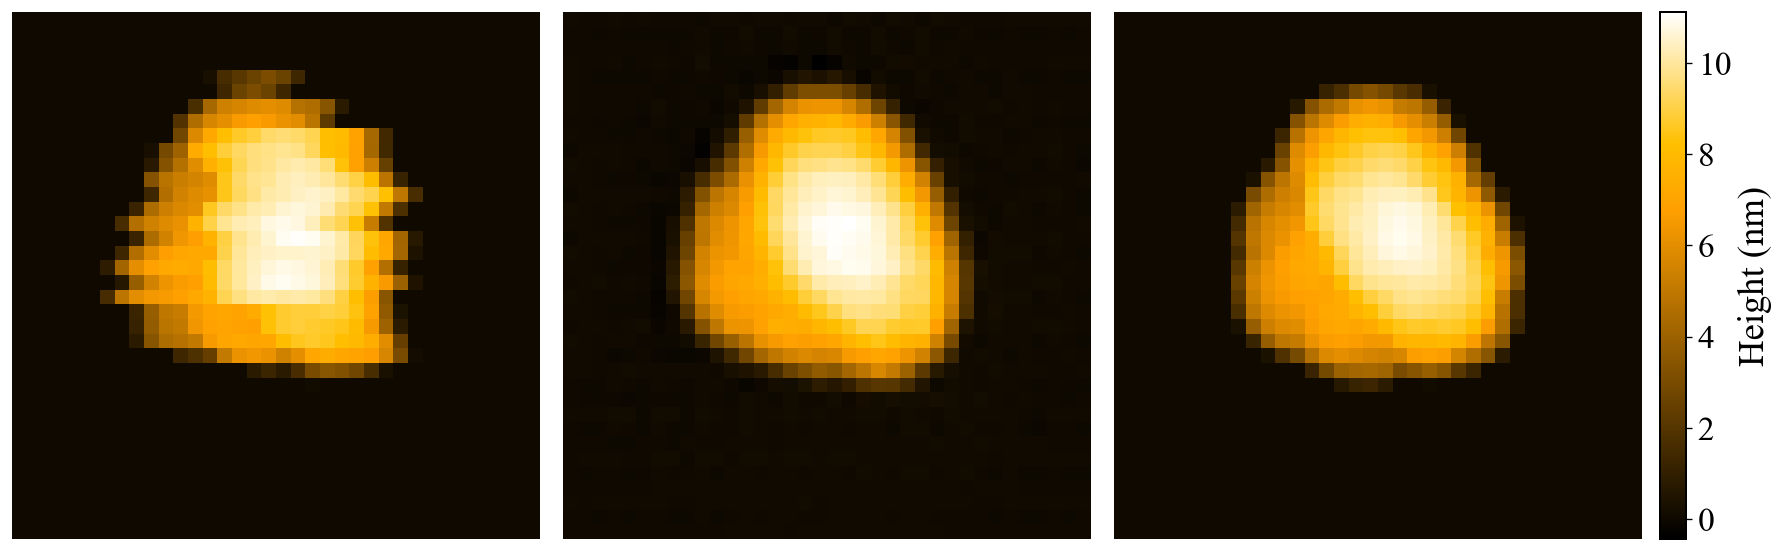

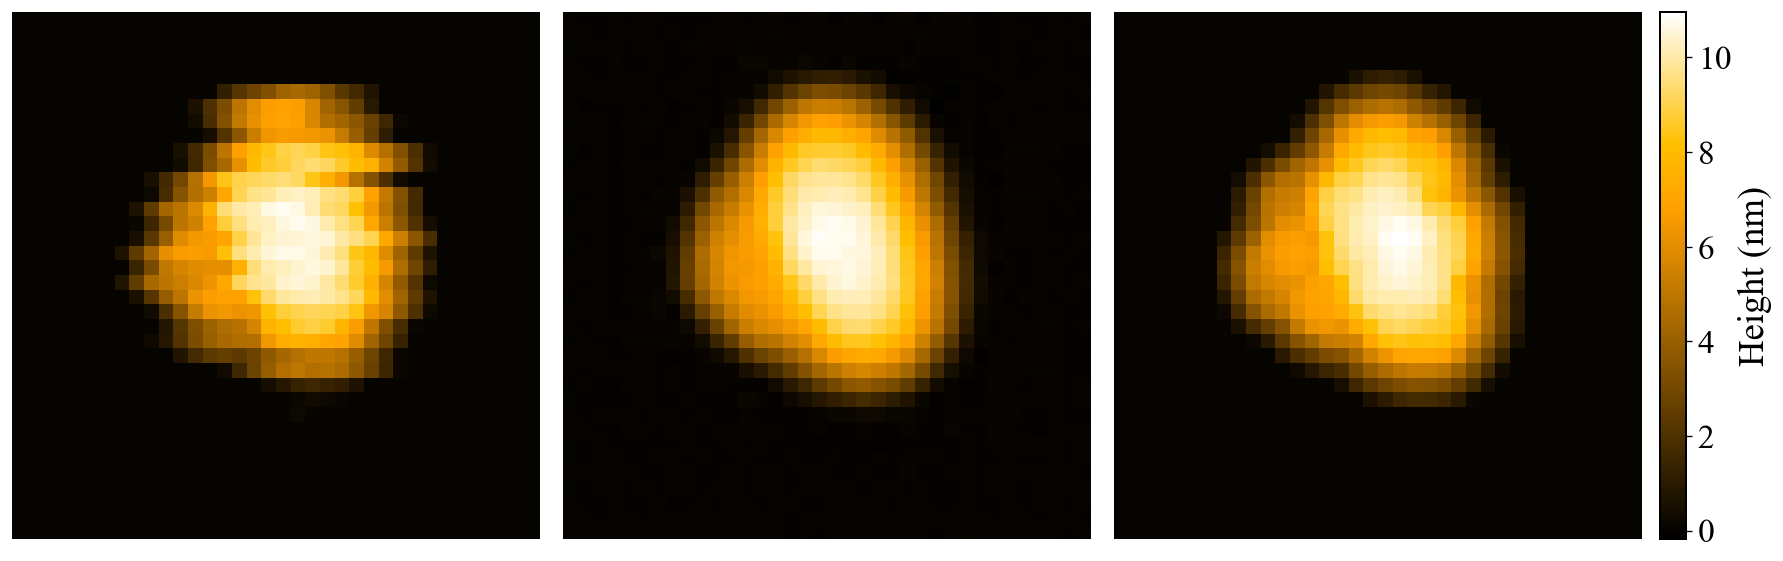

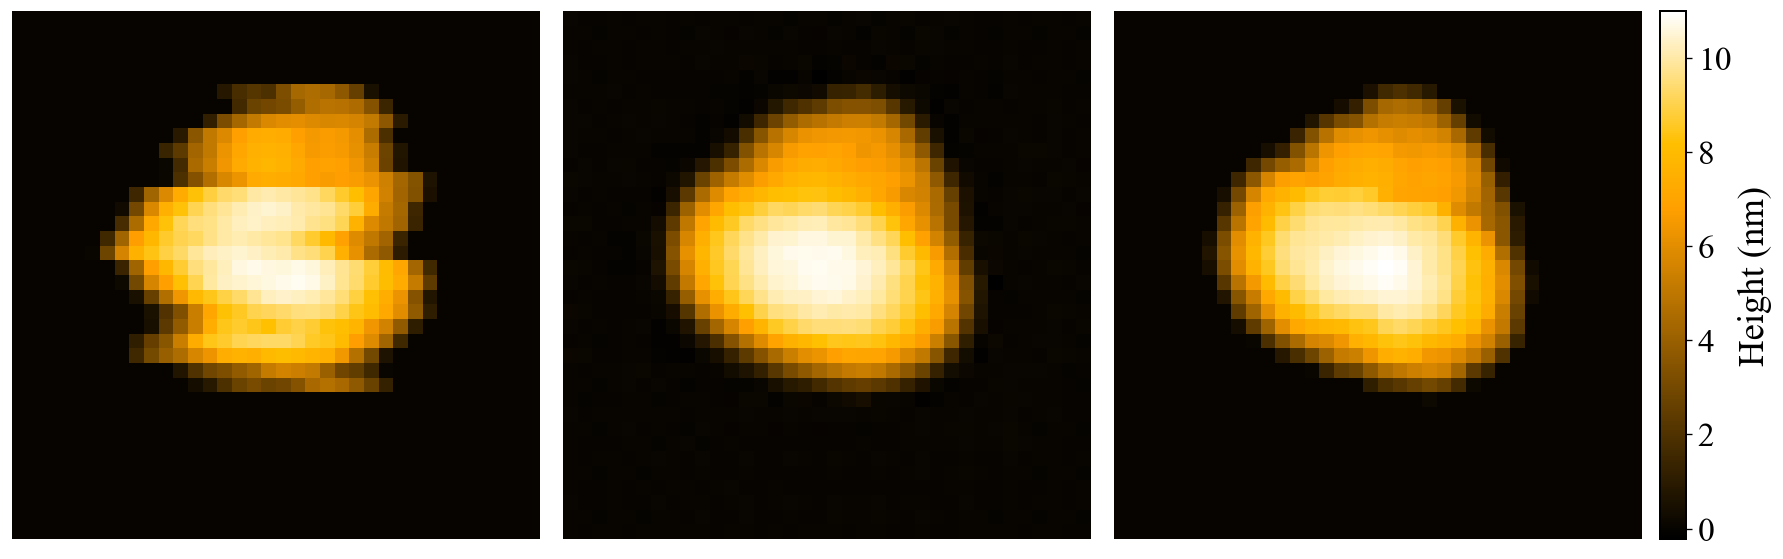

In [18]:
# Visualization
IMG_NUMS = 5
IMAGE_SIZE = exp_cfg.model.image_size

evaluator = Evaluator(
    exp_cfg=exp_cfg, 
    model=model,
    test_data_loader=test_dataloader_for_eval
)

evaluator.load_best_checkpoint()

results = evaluator.compute_loss_and_metrics(
    loss_fn=loss_fn, 
    loss_weights=loss_weights, 
    metrics=metrics
)

print(results)

# MAE MSE (not scaled)
evaluator.compute_physical_metrics(
    dataloader=test_dataloader_for_vis # not scaled is needed for physical metrics
)

# Comprehensive Multi-Task Visualization
evaluator.run_denoise_visualization(
    dataloader=test_dataloader_for_vis,
    num_samples=IMG_NUMS,
    start=(int(IMAGE_SIZE/2), 0),
    angle_deg=0,
    save=False,
    )
